# 🔍 Détection de Fraude — Classification par 3 Méthodes ML
### Random Forest | Logistic Regression | Support Vector Machine

---
**Dataset :** `fraud_transactions_dataset.xlsx`  
**Colonnes :** `Time`, `Amount`, `Transaction_Type`, `Location`, `Is_Fraud`  
**Objectif :** Classifier les transactions comme frauduleuses (1) ou légitimes (0)

## 📦 1. Installation & Importation des bibliothèques

In [1]:
# Installation (si nécessaire)
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    auc, accuracy_score, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

# Style global des graphiques
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})
PALETTE = ['#2ecc71', '#e74c3c']  # vert=légal, rouge=fraude
COLORS = {'RF': '#3498db', 'LR': '#e67e22', 'SVM': '#9b59b6'}

print('✅ Bibliothèques chargées avec succès !')

✅ Bibliothèques chargées avec succès !


## 📂 2. Chargement et exploration des données

In [2]:
# ⚠️ Uploader votre fichier dans Colab : Fichiers > Importer
# ou décommenter la ligne ci-dessous pour Google Drive :
# from google.colab import drive; drive.mount('/content/drive')

from google.colab import files
uploaded = files.upload()  # Sélectionnez fraud_transactions_dataset.xlsx

df = pd.read_excel('fraud_transactions_dataset.xlsx')
print(f'📊 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

Saving fraud_transactions_dataset.xlsx to fraud_transactions_dataset.xlsx
📊 Dimensions : 500 lignes × 5 colonnes


,Time,Amount,Transaction_Type,Location,Is_Fraud
0,68268,917.57,Online,Rural,0
1,43567,1049.66,Online,Rural,0
2,42613,884.59,Online,Rural,0
3,45891,1705.42,Online,Rural,0
4,21243,867.44,Online,Rural,0


In [3]:
print('=== INFOS GÉNÉRALES ===')
df.info()
print('\n=== STATISTIQUES DESCRIPTIVES ===')
display(df.describe())
print('\n=== VALEURS MANQUANTES ===')
print(df.isnull().sum())
print('\n=== DISTRIBUTION DE LA CIBLE ===')
counts = df['Is_Fraud'].value_counts()
print(f"Légitimes (0) : {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Frauduleuses (1) : {counts[1]} ({counts[1]/len(df)*100:.1f}%)")

=== INFOS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Time              500 non-null    int64  
 1   Amount            500 non-null    float64
 2   Transaction_Type  500 non-null    object 
 3   Location          500 non-null    object 
 4   Is_Fraud          500 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 19.7+ KB

=== STATISTIQUES DESCRIPTIVES ===


,Time,Amount,Is_Fraud
count,500.000000,500.000000,500.000000
mean,52727.630000,995.799400,0.058000
std,29283.710541,576.875686,0.233978
min,469.000000,3.410000,0.000000
25%,26586.500000,521.037500,0.000000
50%,54261.000000,1007.855000,0.000000
75%,79871.000000,1445.630000,0.000000
max,99938.000000,1984.870000,1.000000



=== VALEURS MANQUANTES ===
Time                0
Amount              0
Transaction_Type    0
Location            0
Is_Fraud            0
dtype: int64

=== DISTRIBUTION DE LA CIBLE ===
Légitimes (0) : 471 (94.2%)
Frauduleuses (1) : 29 (5.8%)


## 📊 3. Analyse Exploratoire — Visualisations

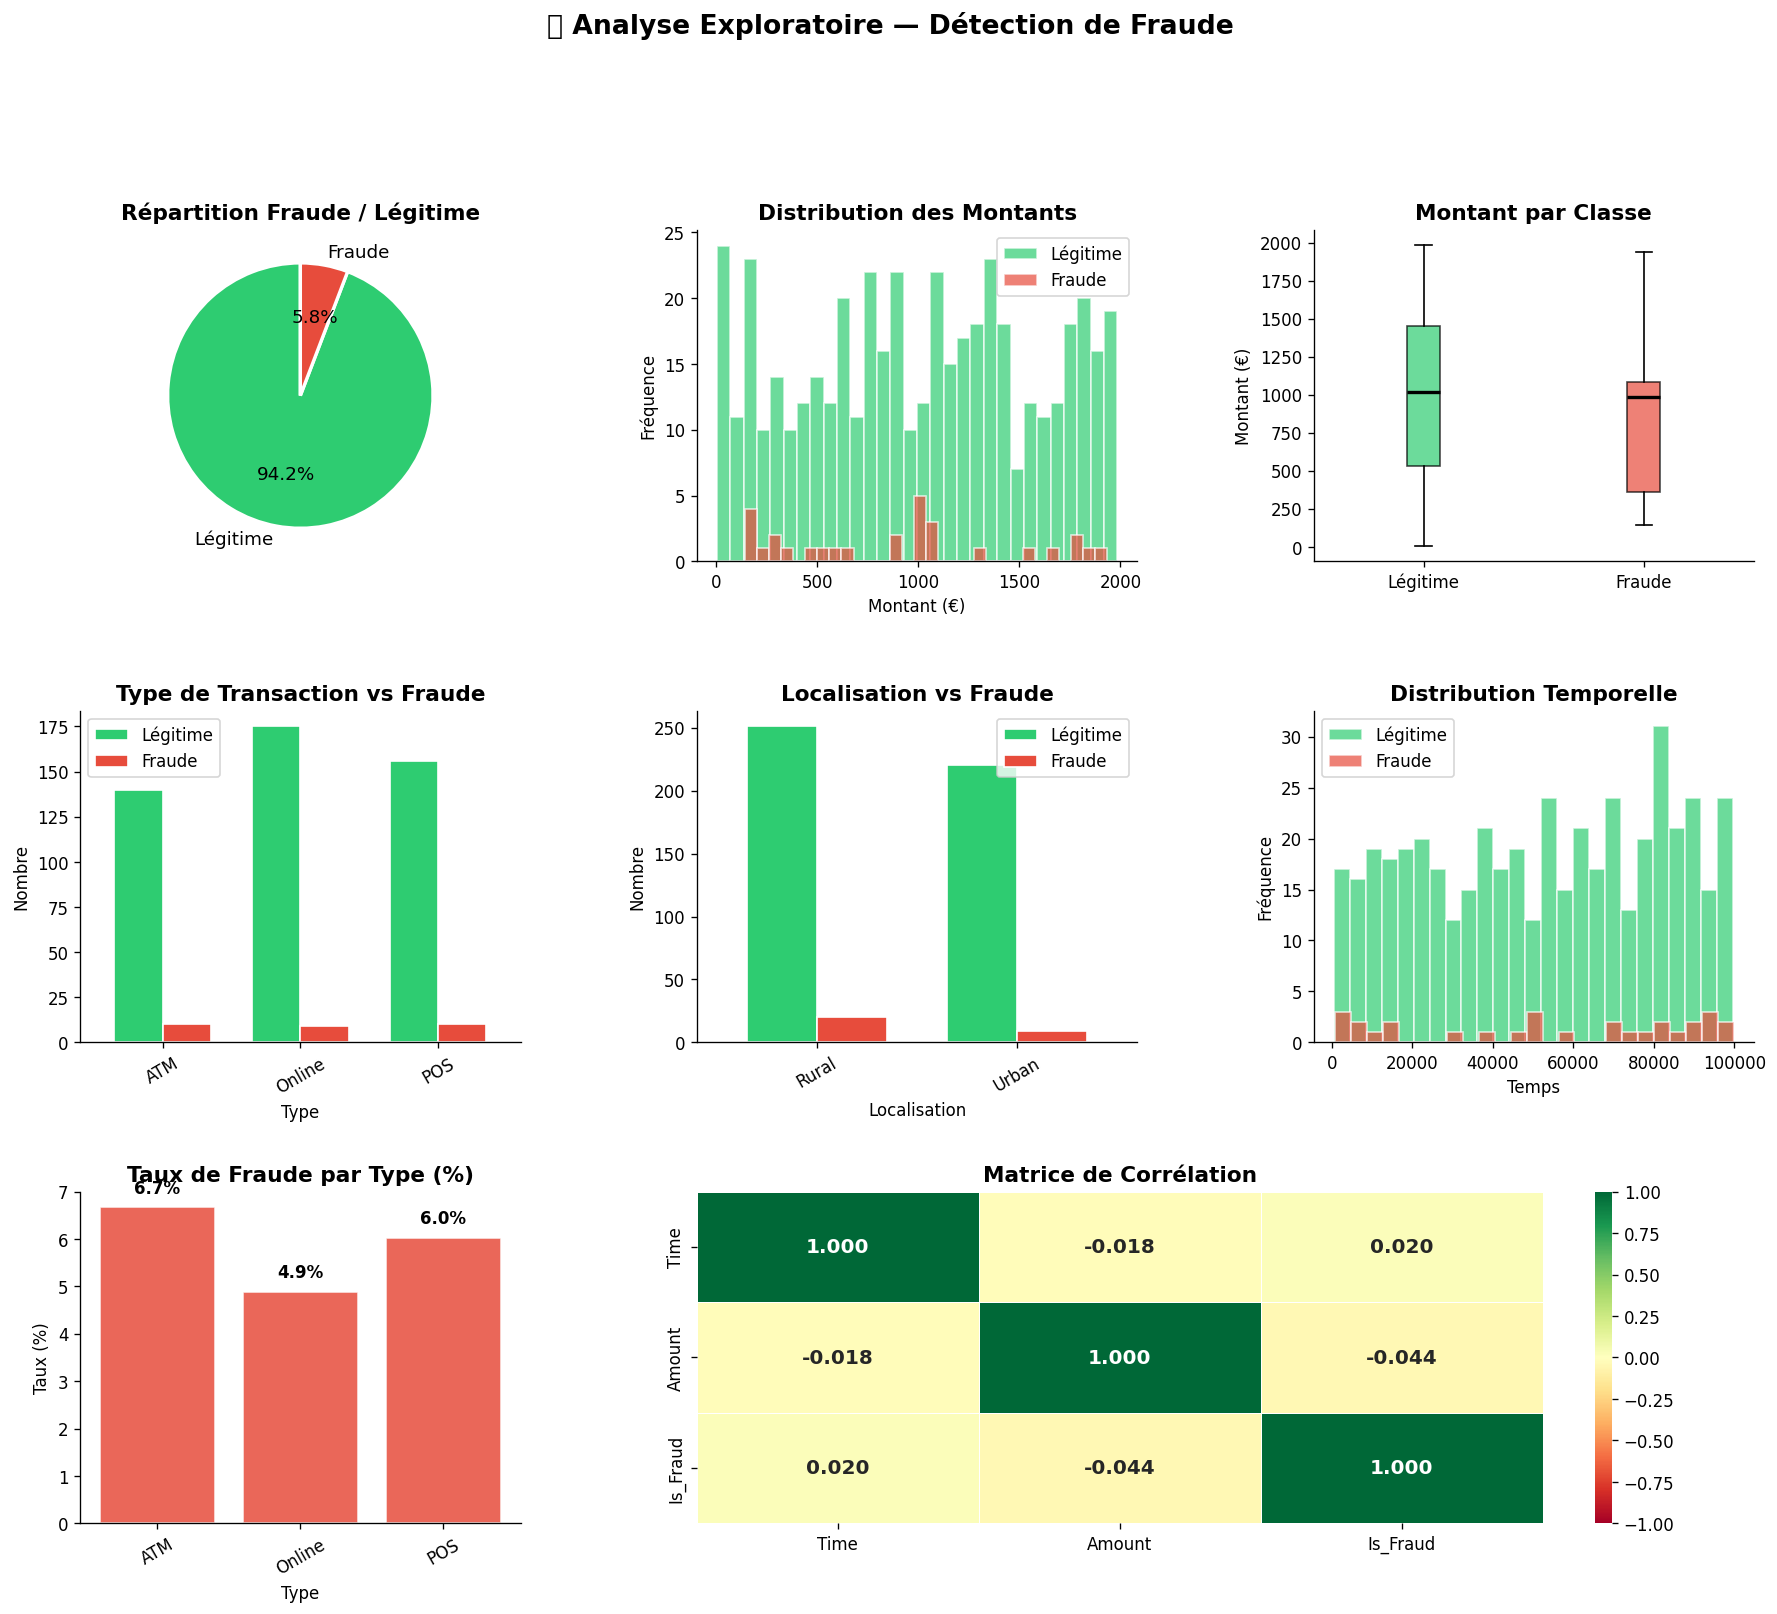

✅ Graphique EDA sauvegardé : 01_eda_fraude.png


In [4]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.4)

# --- 1. Distribution de la cible (pie) ---
ax1 = fig.add_subplot(gs[0, 0])
counts = df['Is_Fraud'].value_counts()
ax1.pie(counts, labels=['Légitime', 'Fraude'], colors=PALETTE,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Répartition Fraude / Légitime', fontsize=13, fontweight='bold')

# --- 2. Distribution du Montant par classe ---
ax2 = fig.add_subplot(gs[0, 1])
for label, color, name in zip([0, 1], PALETTE, ['Légitime', 'Fraude']):
    ax2.hist(df[df['Is_Fraud'] == label]['Amount'], bins=30,
             alpha=0.7, color=color, label=name, edgecolor='white')
ax2.set_xlabel('Montant (€)')
ax2.set_ylabel('Fréquence')
ax2.set_title('Distribution des Montants', fontsize=13, fontweight='bold')
ax2.legend()

# --- 3. Boxplot Montant vs Fraude ---
ax3 = fig.add_subplot(gs[0, 2])
df_box = df.copy()
df_box['Classe'] = df_box['Is_Fraud'].map({0: 'Légitime', 1: 'Fraude'})
ax3.boxplot([df[df['Is_Fraud'] == 0]['Amount'], df[df['Is_Fraud'] == 1]['Amount']],
            labels=['Légitime', 'Fraude'],
            patch_artist=True,
            boxprops=dict(facecolor=PALETTE[0], alpha=0.7),
            medianprops=dict(color='black', linewidth=2))
boxes = ax3.findobj(plt.matplotlib.patches.PathPatch)
for i, box in enumerate(boxes):
    box.set_facecolor(PALETTE[i % 2])
ax3.set_title('Montant par Classe', fontsize=13, fontweight='bold')
ax3.set_ylabel('Montant (€)')

# --- 4. Transaction_Type vs Fraude ---
ax4 = fig.add_subplot(gs[1, 0])
ct = pd.crosstab(df['Transaction_Type'], df['Is_Fraud'])
ct.columns = ['Légitime', 'Fraude']
ct.plot(kind='bar', ax=ax4, color=PALETTE, edgecolor='white', width=0.7)
ax4.set_title('Type de Transaction vs Fraude', fontsize=13, fontweight='bold')
ax4.set_xlabel('Type')
ax4.set_ylabel('Nombre')
ax4.tick_params(axis='x', rotation=30)
ax4.legend()

# --- 5. Location vs Fraude ---
ax5 = fig.add_subplot(gs[1, 1])
ct2 = pd.crosstab(df['Location'], df['Is_Fraud'])
ct2.columns = ['Légitime', 'Fraude']
ct2.plot(kind='bar', ax=ax5, color=PALETTE, edgecolor='white', width=0.7)
ax5.set_title('Localisation vs Fraude', fontsize=13, fontweight='bold')
ax5.set_xlabel('Localisation')
ax5.set_ylabel('Nombre')
ax5.tick_params(axis='x', rotation=30)
ax5.legend()

# --- 6. Time vs Fraude ---
ax6 = fig.add_subplot(gs[1, 2])
for label, color, name in zip([0, 1], PALETTE, ['Légitime', 'Fraude']):
    ax6.hist(df[df['Is_Fraud'] == label]['Time'], bins=25,
             alpha=0.7, color=color, label=name, edgecolor='white')
ax6.set_xlabel('Temps')
ax6.set_ylabel('Fréquence')
ax6.set_title('Distribution Temporelle', fontsize=13, fontweight='bold')
ax6.legend()

# --- 7. Taux de fraude par type ---
ax7 = fig.add_subplot(gs[2, 0])
fraud_rate = df.groupby('Transaction_Type')['Is_Fraud'].mean() * 100
bars = ax7.bar(fraud_rate.index, fraud_rate.values, color='#e74c3c', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, fraud_rate.values):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax7.set_title('Taux de Fraude par Type (%)', fontsize=13, fontweight='bold')
ax7.set_xlabel('Type')
ax7.set_ylabel('Taux (%)')
ax7.tick_params(axis='x', rotation=30)

# --- 8. Corrélation ---
ax8 = fig.add_subplot(gs[2, 1:])
df_num = df[['Time', 'Amount', 'Is_Fraud']]
corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax8, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
ax8.set_title('Matrice de Corrélation', fontsize=13, fontweight='bold')

fig.suptitle('🔍 Analyse Exploratoire — Détection de Fraude',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('01_eda_fraude.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Graphique EDA sauvegardé : 01_eda_fraude.png')

## ⚙️ 4. Prétraitement des données

In [5]:
df_processed = df.copy()

# Encodage des variables catégorielles
le_type = LabelEncoder()
le_loc  = LabelEncoder()
df_processed['Transaction_Type_enc'] = le_type.fit_transform(df_processed['Transaction_Type'])
df_processed['Location_enc']         = le_loc.fit_transform(df_processed['Location'])

print('Transaction_Type mapping :', dict(zip(le_type.classes_, le_type.transform(le_type.classes_))))
print('Location mapping         :', dict(zip(le_loc.classes_, le_loc.transform(le_loc.classes_))))

# Features et cible
FEATURES = ['Time', 'Amount', 'Transaction_Type_enc', 'Location_enc']
X = df_processed[FEATURES]
y = df_processed['Is_Fraud']

# Split 80/20 stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\n✅ Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f'Fraudes dans le train : {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Fraudes dans le test  : {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Transaction_Type mapping : {'ATM': np.int64(0), 'Online': np.int64(1), 'POS': np.int64(2)}
Location mapping         : {'Rural': np.int64(0), 'Urban': np.int64(1)}

✅ Train : 400 | Test : 100
Fraudes dans le train : 23 (5.8%)
Fraudes dans le test  : 6 (6.0%)


## 🌲 5. Méthode 1 — Random Forest

In [6]:
print('=' * 55)
print('   🌲  RANDOM FOREST CLASSIFIER')
print('=' * 55)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)
y_pred_rf    = rf.predict(X_test_sc)
y_proba_rf   = rf.predict_proba(X_test_sc)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)

print(f'\n📊 Accuracy  : {acc_rf:.4f}')
print(f'📊 F1-Score  : {f1_rf:.4f}')
print(f'📊 Precision : {prec_rf:.4f}')
print(f'📊 Recall    : {rec_rf:.4f}')
print('\nRapport de Classification :')
print(classification_report(y_test, y_pred_rf, target_names=['Légitime', 'Fraude']))

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='f1')
print(f'CV F1 (5-fold): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')

   🌲  RANDOM FOREST CLASSIFIER

📊 Accuracy  : 0.9300
📊 F1-Score  : 0.0000
📊 Precision : 0.0000
📊 Recall    : 0.0000

Rapport de Classification :
              precision    recall  f1-score   support

    Légitime       0.94      0.99      0.96        94
      Fraude       0.00      0.00      0.00         6

    accuracy                           0.93       100
   macro avg       0.47      0.49      0.48       100
weighted avg       0.88      0.93      0.91       100

CV F1 (5-fold): 0.0000 ± 0.0000


## 📈 6. Méthode 2 — Logistic Regression

In [7]:
print('=' * 55)
print('   📈  LOGISTIC REGRESSION')
print('=' * 55)

lr = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train_sc, y_train)
y_pred_lr   = lr.predict(X_test_sc)
y_proba_lr  = lr.predict_proba(X_test_sc)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)

print(f'\n📊 Accuracy  : {acc_lr:.4f}')
print(f'📊 F1-Score  : {f1_lr:.4f}')
print(f'📊 Precision : {prec_lr:.4f}')
print(f'📊 Recall    : {rec_lr:.4f}')
print('\nRapport de Classification :')
print(classification_report(y_test, y_pred_lr, target_names=['Légitime', 'Fraude']))

cv_scores_lr = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='f1')
print(f'CV F1 (5-fold): {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')

   📈  LOGISTIC REGRESSION

📊 Accuracy  : 0.4600
📊 F1-Score  : 0.1000
📊 Precision : 0.0556
📊 Recall    : 0.5000

Rapport de Classification :
              precision    recall  f1-score   support

    Légitime       0.93      0.46      0.61        94
      Fraude       0.06      0.50      0.10         6

    accuracy                           0.46       100
   macro avg       0.50      0.48      0.36       100
weighted avg       0.88      0.46      0.58       100

CV F1 (5-fold): 0.1221 ± 0.0357


## 🔷 7. Méthode 3 — Support Vector Machine

In [8]:
print('=' * 55)
print('   🔷  SUPPORT VECTOR MACHINE')
print('=' * 55)

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train_sc, y_train)
y_pred_svm  = svm.predict(X_test_sc)
y_proba_svm = svm.predict_proba(X_test_sc)[:, 1]

acc_svm  = accuracy_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm  = recall_score(y_test, y_pred_svm)

print(f'\n📊 Accuracy  : {acc_svm:.4f}')
print(f'📊 F1-Score  : {f1_svm:.4f}')
print(f'📊 Precision : {prec_svm:.4f}')
print(f'📊 Recall    : {rec_svm:.4f}')
print('\nRapport de Classification :')
print(classification_report(y_test, y_pred_svm, target_names=['Légitime', 'Fraude']))

cv_scores_svm = cross_val_score(svm, X_train_sc, y_train, cv=cv, scoring='f1')
print(f'CV F1 (5-fold): {cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}')

   🔷  SUPPORT VECTOR MACHINE

📊 Accuracy  : 0.6300
📊 F1-Score  : 0.1395
📊 Precision : 0.0811
📊 Recall    : 0.5000

Rapport de Classification :
              precision    recall  f1-score   support

    Légitime       0.95      0.64      0.76        94
      Fraude       0.08      0.50      0.14         6

    accuracy                           0.63       100
   macro avg       0.52      0.57      0.45       100
weighted avg       0.90      0.63      0.73       100

CV F1 (5-fold): 0.1175 ± 0.0480


## 📊 8. Visualisation — Matrices de Confusion

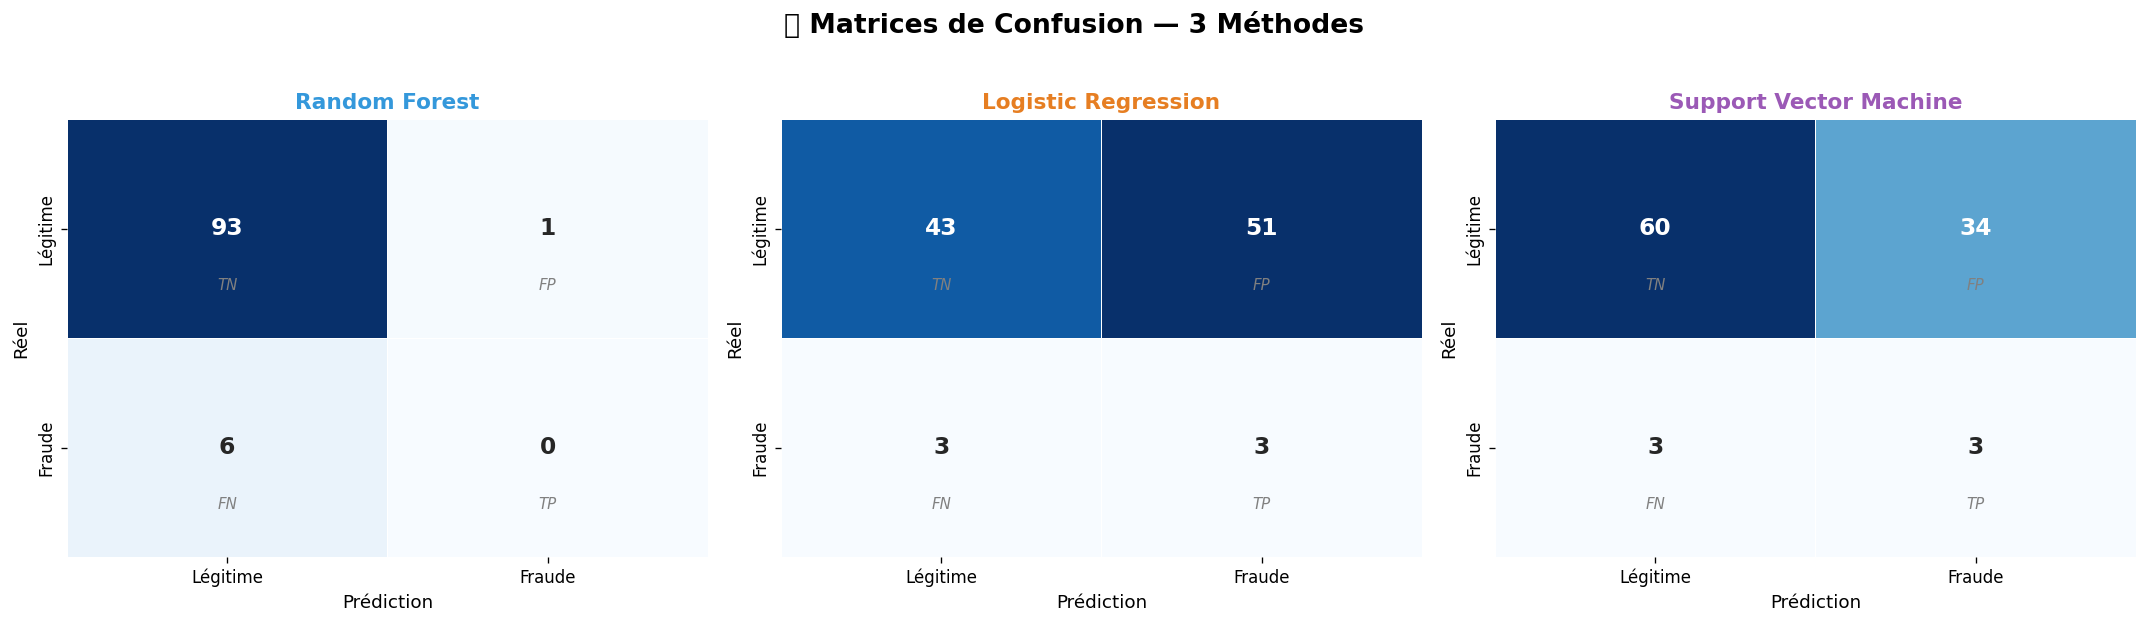

✅ Sauvegardé : 02_confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ('Random Forest',        y_pred_rf,  COLORS['RF']),
    ('Logistic Regression',  y_pred_lr,  COLORS['LR']),
    ('Support Vector Machine', y_pred_svm, COLORS['SVM'])
]

for ax, (name, y_pred, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Légitime', 'Fraude'],
                yticklabels=['Légitime', 'Fraude'],
                linewidths=0.5, cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{name}', fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Prédiction', fontsize=11)
    ax.set_ylabel('Réel', fontsize=11)

    # Annotations TN/FP/FN/TP
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.78, labels[i][j],
                    ha='center', fontsize=9, color='gray', style='italic')

fig.suptitle('🔷 Matrices de Confusion — 3 Méthodes',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('02_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Sauvegardé : 02_confusion_matrices.png')

## 📉 9. Courbes ROC — Comparaison des 3 Modèles

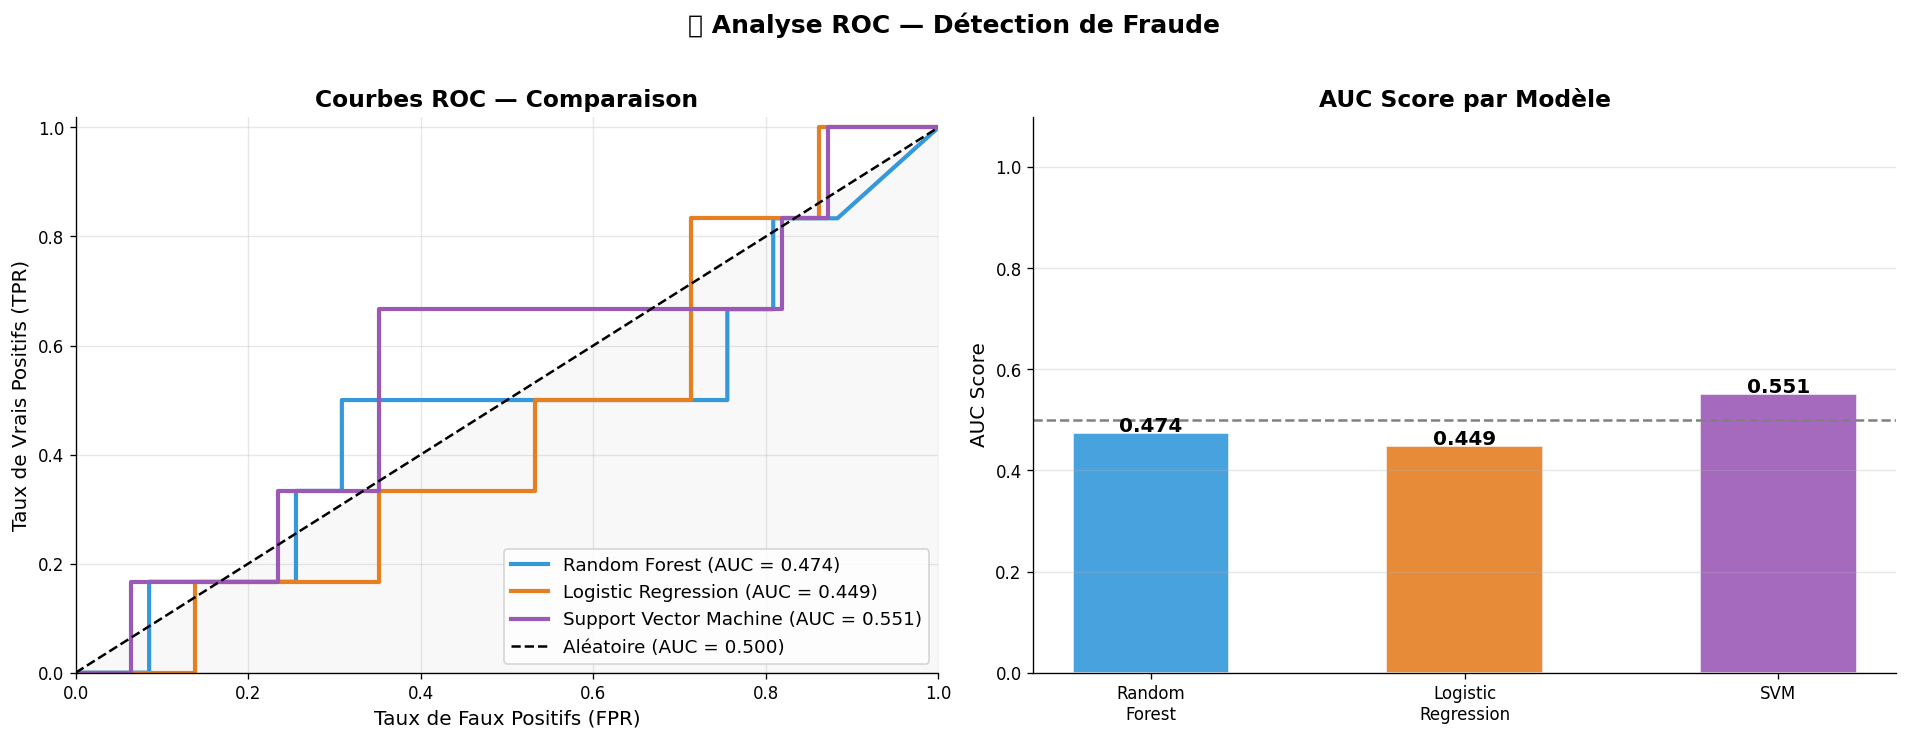

✅ Sauvegardé : 03_roc_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gauche : ROC individuelle ---
ax = axes[0]
models_roc = [
    ('Random Forest',          y_proba_rf,  COLORS['RF']),
    ('Logistic Regression',    y_proba_lr,  COLORS['LR']),
    ('Support Vector Machine', y_proba_svm, COLORS['SVM'])
]

for name, proba, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aléatoire (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)

# --- Droite : AUC barplot ---
ax2 = axes[1]
names = ['Random\nForest', 'Logistic\nRegression', 'SVM']
colors_list = [COLORS['RF'], COLORS['LR'], COLORS['SVM']]
aucs = []
for name, proba, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    aucs.append(auc(fpr, tpr))

bars = ax2.bar(names, aucs, color=colors_list, edgecolor='white', width=0.5, alpha=0.9)
for bar, val in zip(bars, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Baseline')
ax2.set_ylim([0, 1.1])
ax2.set_ylabel('AUC Score', fontsize=12)
ax2.set_title('AUC Score par Modèle', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('📉 Analyse ROC — Détection de Fraude',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Sauvegardé : 03_roc_curves.png')

## 🏆 10. Comparaison Globale des Performances

In [11]:
# Récupération AUC
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_proba_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)

results = pd.DataFrame({
    'Modèle':     ['Random Forest', 'Logistic Regression', 'SVM'],
    'Accuracy':   [acc_rf, acc_lr, acc_svm],
    'Precision':  [prec_rf, prec_lr, prec_svm],
    'Recall':     [rec_rf, rec_lr, rec_svm],
    'F1-Score':   [f1_rf, f1_lr, f1_svm],
    'AUC':        [auc(fpr_rf, tpr_rf), auc(fpr_lr, tpr_lr), auc(fpr_svm, tpr_svm)],
    'CV F1 (mean)': [cv_scores_rf.mean(), cv_scores_lr.mean(), cv_scores_svm.mean()],
    'CV F1 (std)':  [cv_scores_rf.std(), cv_scores_lr.std(), cv_scores_svm.std()]
}).set_index('Modèle')

print('\n=== TABLEAU COMPARATIF COMPLET ===')
display(results.round(4).style
        .background_gradient(cmap='YlOrRd', subset=['F1-Score', 'AUC', 'Recall'])
        .format('{:.4f}'))

best = results['F1-Score'].idxmax()
print(f'\n🏆 Meilleur modèle (F1-Score) : {best}')


=== TABLEAU COMPARATIF COMPLET ===


,Accuracy,Precision,Recall,F1-Score,AUC,CV F1 (mean),CV F1 (std)
Modèle,,,,,,,
Random Forest,0.9300,0.0000,0.0000,0.0000,0.4743,0.0000,0.0000
Logistic Regression,0.4600,0.0556,0.5000,0.1000,0.4486,0.1221,0.0357
SVM,0.6300,0.0811,0.5000,0.1395,0.5514,0.1175,0.0480



🏆 Meilleur modèle (F1-Score) : SVM


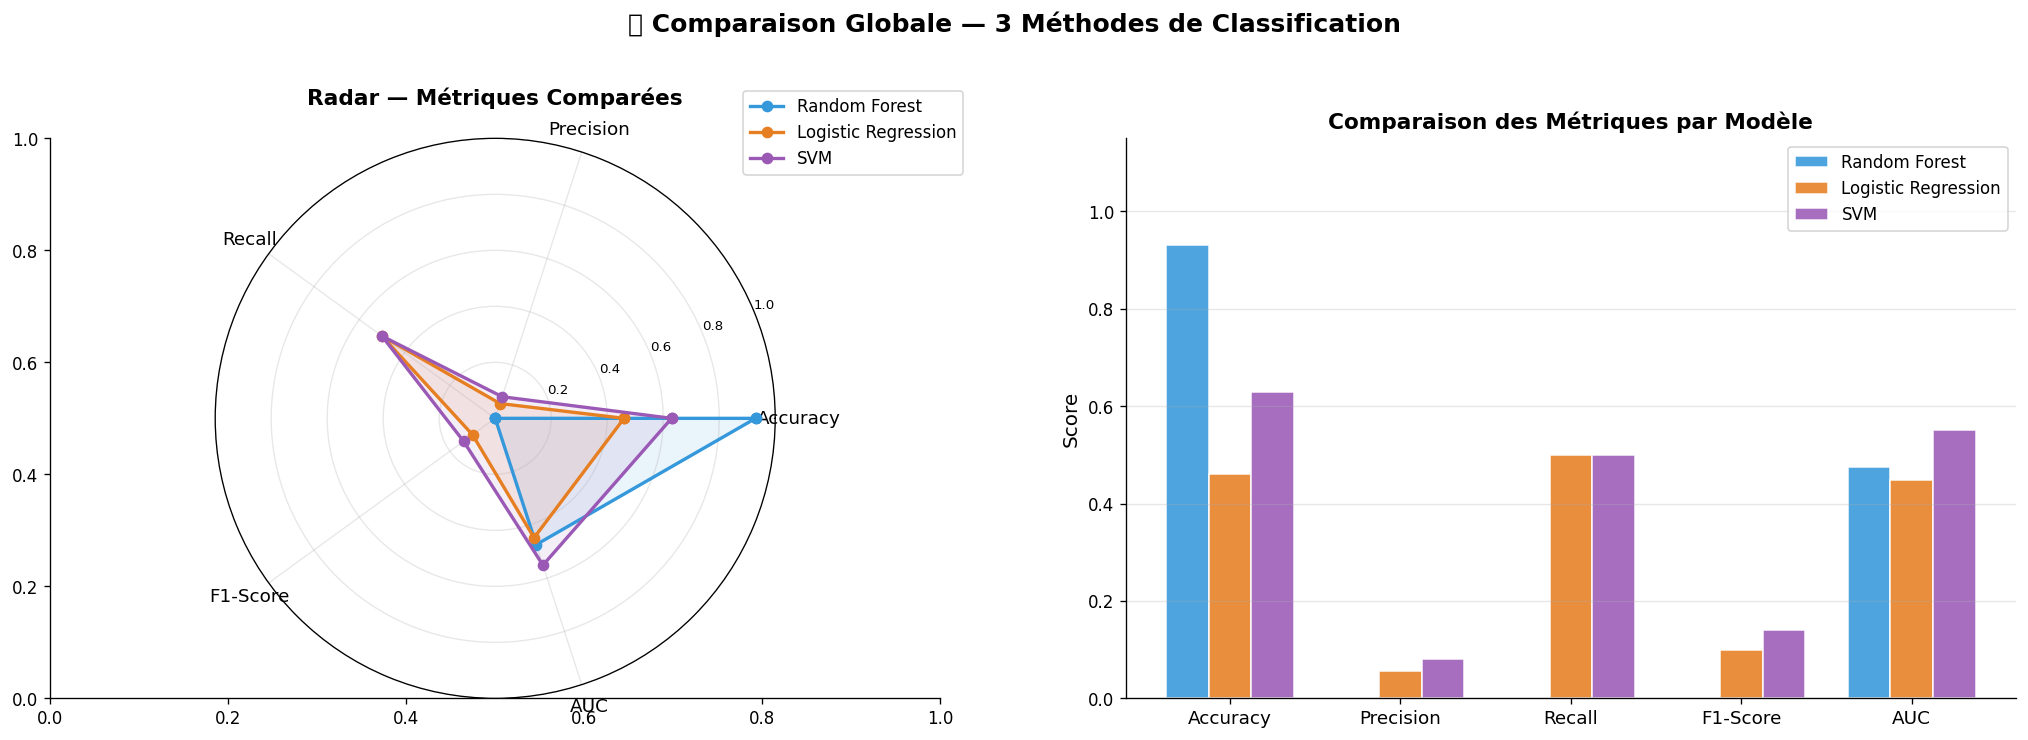

✅ Sauvegardé : 04_comparaison_modeles.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# --- Radar Chart ---
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
N         = len(metrics)
angles    = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles   += angles[:1]

ax_radar = fig.add_subplot(121, polar=True)
model_names = ['Random Forest', 'Logistic Regression', 'SVM']
colors_radar = [COLORS['RF'], COLORS['LR'], COLORS['SVM']]

for model, color in zip(model_names, colors_radar):
    values = results.loc[model, metrics].tolist()
    values += values[:1]
    ax_radar.plot(angles, values, 'o-', linewidth=2, color=color, label=model)
    ax_radar.fill(angles, values, alpha=0.1, color=color)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metrics, size=11)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_radar.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=8)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax_radar.set_title('Radar — Métriques Comparées', fontsize=13, fontweight='bold', pad=20)
ax_radar.grid(True, alpha=0.3)

# --- Grouped Bar Chart ---
ax2 = axes[1]
x    = np.arange(len(metrics))
width = 0.25

for i, (model, color) in enumerate(zip(model_names, colors_radar)):
    vals = results.loc[model, metrics].values
    bars = ax2.bar(x + i * width, vals, width, label=model, color=color,
                   edgecolor='white', alpha=0.88)

ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics, fontsize=11)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Comparaison des Métriques par Modèle', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('🏆 Comparaison Globale — 3 Méthodes de Classification',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_comparaison_modeles.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Sauvegardé : 04_comparaison_modeles.png')

## 🔎 11. Importance des Features (Random Forest)

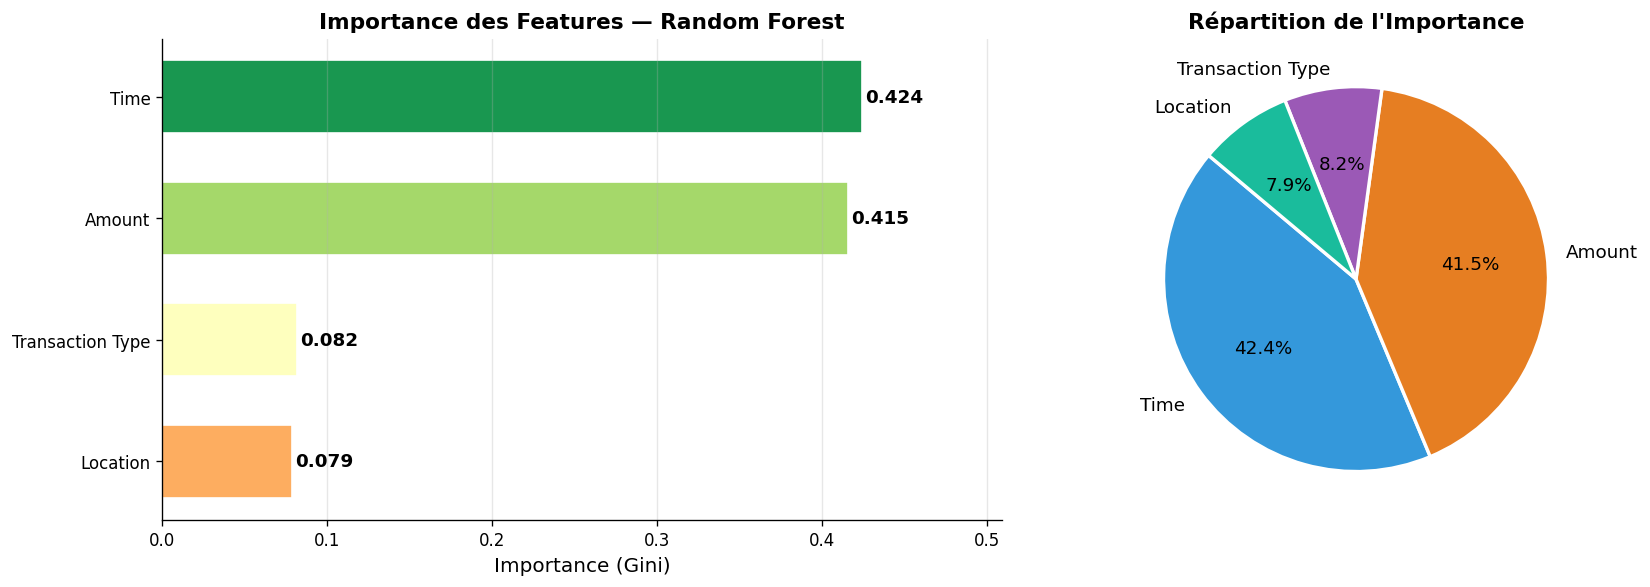

✅ Sauvegardé : 05_feature_importance.png


In [13]:
feat_names = ['Time', 'Amount', 'Transaction Type', 'Location']
importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barplot horizontal
ax = axes[0]
sorted_idx = np.argsort(importances)
colors_feat = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_names)))
bars = ax.barh([feat_names[i] for i in sorted_idx], importances[sorted_idx],
               color=colors_feat, edgecolor='white', height=0.6)
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Importance (Gini)', fontsize=12)
ax.set_title('Importance des Features — Random Forest', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(importances) * 1.2)

# Pie chart
ax2 = axes[1]
colors_pie = [COLORS['RF'], COLORS['LR'], COLORS['SVM'], '#1abc9c']
wedges, texts, autotexts = ax2.pie(
    importances[indices],
    labels=[feat_names[i] for i in indices],
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax2.set_title('Répartition de l\'Importance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('05_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Sauvegardé : 05_feature_importance.png')

## 📊 12. Scores de Cross-Validation

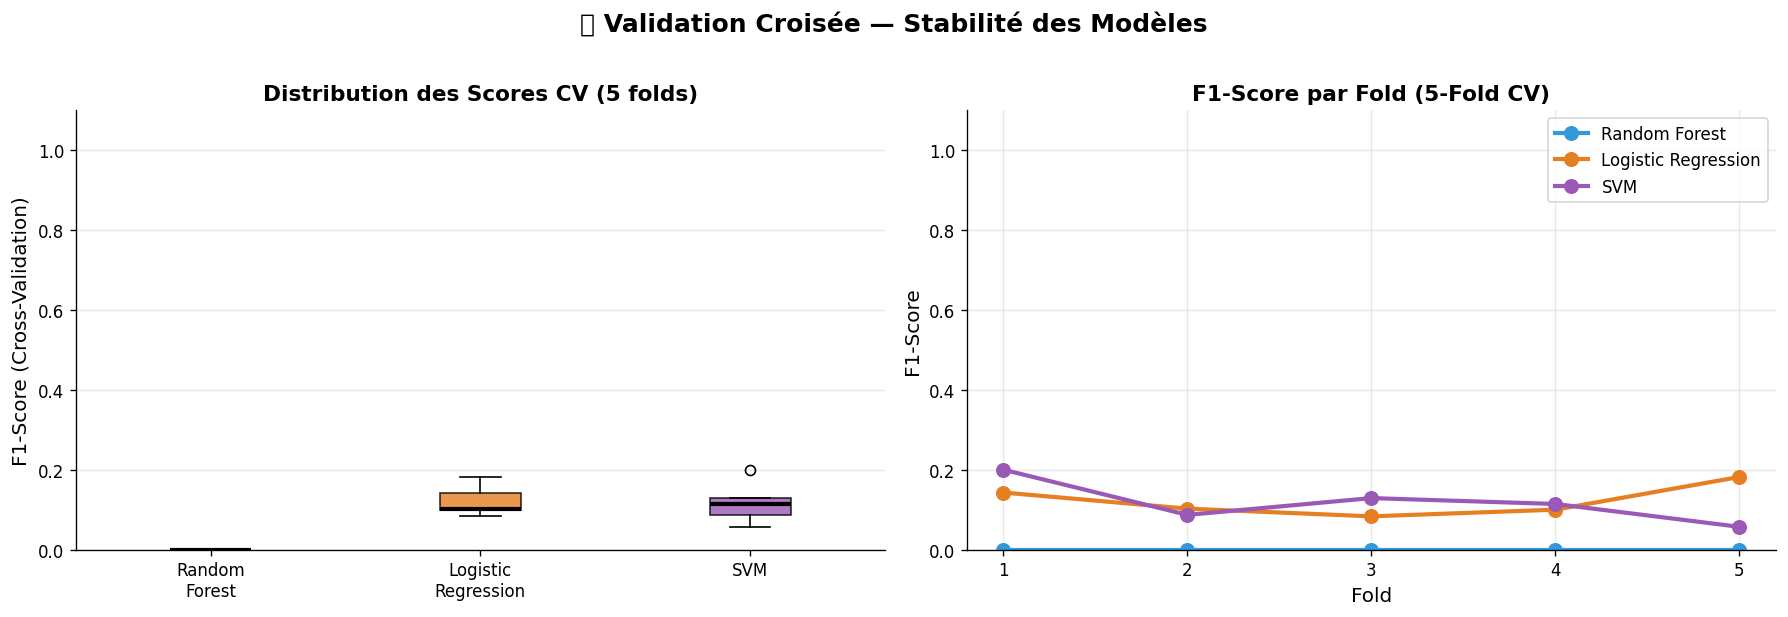

✅ Sauvegardé : 06_cross_validation.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

all_cv_scores = {
    'Random\nForest': cv_scores_rf,
    'Logistic\nRegression': cv_scores_lr,
    'SVM': cv_scores_svm
}

# Boxplot CV
ax1 = axes[0]
bp = ax1.boxplot(list(all_cv_scores.values()),
                 labels=list(all_cv_scores.keys()),
                 patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2.5))
for patch, color in zip(bp['boxes'], colors_radar):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax1.set_ylabel('F1-Score (Cross-Validation)', fontsize=12)
ax1.set_title('Distribution des Scores CV (5 folds)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1.1)

# Line plot fold par fold
ax2 = axes[1]
folds = list(range(1, 6))
for (name, scores), color in zip(all_cv_scores.items(), colors_radar):
    ax2.plot(folds, scores, 'o-', color=color,
             label=name.replace('\n', ' '), lw=2.5, markersize=8)
ax2.set_xlabel('Fold', fontsize=12)
ax2.set_ylabel('F1-Score', fontsize=12)
ax2.set_title('F1-Score par Fold (5-Fold CV)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xticks(folds)
ax2.set_ylim(0, 1.1)
ax2.grid(alpha=0.3)

fig.suptitle('🔄 Validation Croisée — Stabilité des Modèles',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Sauvegardé : 06_cross_validation.png')

## 🏁 13. Résumé Final & Recommandations

In [15]:
best_f1  = results['F1-Score'].idxmax()
best_auc = results['AUC'].idxmax()
best_rec = results['Recall'].idxmax()

print('=' * 65)
print('   🏁  RÉSUMÉ FINAL — DÉTECTION DE FRAUDE')
print('=' * 65)
print()
display(results[['Accuracy','Precision','Recall','F1-Score','AUC']].round(4))
print()
print(f'🥇 Meilleur F1-Score  → {best_f1} ({results.loc[best_f1,"F1-Score"]:.4f})')
print(f'🥇 Meilleur AUC       → {best_auc} ({results.loc[best_auc,"AUC"]:.4f})')
print(f'🥇 Meilleur Recall    → {best_rec} ({results.loc[best_rec,"Recall"]:.4f})')
print()
print('─' * 65)
print('💡 RECOMMANDATIONS :')
print()
print('  🌲 Random Forest     → Robuste, gère bien les non-linéarités,')
print('                          importance des features disponible.')
print()
print('  📈 Logistic Reg.     → Interprétable, rapide, bon pour les')
print('                          relations linéaires.')
print()
print('  🔷 SVM (RBF)         → Efficace sur petits datasets, bonne')
print('                          généralisation avec kernel non-linéaire.')
print()
print('  ⭐ En production :    → Privilégier le Recall (détecter max')
print('                          de fraudes) tout en contrôlant la')
print('                          Precision (éviter faux positifs).')
print('─' * 65)

print('\n📁 Graphiques générés :')
for f in ['01_eda_fraude.png','02_confusion_matrices.png','03_roc_curves.png',
          '04_comparaison_modeles.png','05_feature_importance.png','06_cross_validation.png']:
    print(f'   ✅ {f}')

   🏁  RÉSUMÉ FINAL — DÉTECTION DE FRAUDE



,Accuracy,Precision,Recall,F1-Score,AUC
Modèle,,,,,
Random Forest,0.93,0.0000,0.0,0.0000,0.4743
Logistic Regression,0.46,0.0556,0.5,0.1000,0.4486
SVM,0.63,0.0811,0.5,0.1395,0.5514



🥇 Meilleur F1-Score  → SVM (0.1395)
🥇 Meilleur AUC       → SVM (0.5514)
🥇 Meilleur Recall    → Logistic Regression (0.5000)

─────────────────────────────────────────────────────────────────
💡 RECOMMANDATIONS :

  🌲 Random Forest     → Robuste, gère bien les non-linéarités,
                          importance des features disponible.

  📈 Logistic Reg.     → Interprétable, rapide, bon pour les
                          relations linéaires.

  🔷 SVM (RBF)         → Efficace sur petits datasets, bonne
                          généralisation avec kernel non-linéaire.

  ⭐ En production :    → Privilégier le Recall (détecter max
                          de fraudes) tout en contrôlant la
                          Precision (éviter faux positifs).
─────────────────────────────────────────────────────────────────

📁 Graphiques générés :
   ✅ 01_eda_fraude.png
   ✅ 02_confusion_matrices.png
   ✅ 03_roc_curves.png
   ✅ 04_comparaison_modeles.png
   ✅ 05_feature_importance.png
   ✅ 06_cross_